# **Research/Learn:** End-to-end flow
(postcode → lat/long → NASA data → model
inference → 365 next days solar generation output).

In [1]:
!pip install "chronos-forecasting>=2.0.0" accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!pip install transformers datasets gluonts chronos pandas requests

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.8 MB/s eta 0:00:00
  Created wheel for chronos: filename=chronos-0.3-py3-none-any.whl size=7373 sha256=8c6ac6661c1c4e4cf4c2b2a710d2ca1635717a6a7c302d4cd14c58e3df3fb39e
  Stored in directory: /root/.cache/pip/wheels/b5/9c/d5/1dbbab8b167406e7058cf3c96fa031b98ef022b893a66c634a
Successfully built chronos


In [3]:
!pip install autogluon.timeseries autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 15.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter co

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import requests
import joblib
import matplotlib.pyplot as plt
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

class SolarForecastingPipeline:
    def __init__(self, model_path, df_main):

        self.model_path = model_path # finetuned predictor model path
        self.df_main = df_main      #data frame of datasets(18K)
        self.predictor = None  #predictor model

    def load_models(self):
        """ Loading model  AutoGloun """

        self.predictor = TimeSeriesPredictor.load(self.model_path)
        print("Successful loading model!")

    def get_station_from_postcode(self, postcode):
        row = self.df_main[self.df_main["postcode"] == postcode]

        if row.empty:
            raise ValueError(f"Không tìm thấy postcode trong lookup table: {postcode}")

        # Vì bảng lookup đã xử lý mỗi postcode chỉ có 1 dòng
        row = row.iloc[0]

        return {
            "solar_ref_id": row["solar_ref_id"],
            "lat": row["ref_lat"],
            "long": row["ref_long"],
        }

    def build_future_weather_from_last_2_years(
            self,
            context_weather_df,
            forecast_start,
            prediction_length=365
        ):
            """
            Build future weather covariates by averaging weather values
            from the same calendar dates in the previous 2 years.

            Example:
            future date 2026-01-01 =
                mean(weather 2025-01-01, weather 2024-01-01)
            """

            weather_cols = [
                "ALLSKY_SFC_SW_DWN",
                "T2M",
                "WS2M",
                "RH2M"
            ]

            df = context_weather_df.copy()
            df["date"] = pd.to_datetime(df["date"])
            df = df.set_index("date").sort_index()

            forecast_start = pd.to_datetime(forecast_start)

            future_dates = pd.date_range(
                start=forecast_start,
                periods=prediction_length,
                freq="D"
            )

            rows = []

            for future_date in future_dates:
                date_1y = future_date - pd.DateOffset(years=1)
                date_2y = future_date - pd.DateOffset(years=2)

                candidates = []

                if date_1y in df.index:
                    candidates.append(df.loc[date_1y, weather_cols])

                if date_2y in df.index:
                    candidates.append(df.loc[date_2y, weather_cols])

                if candidates:
                    avg_weather = pd.concat(candidates, axis=1).mean(axis=1)
                else:
                    # fallback nếu lệch ngày do leap year hoặc thiếu dữ liệu
                    same_doy = df[df.index.dayofyear == future_date.dayofyear]
                    avg_weather = same_doy[weather_cols].mean()

                row = {
                    "date": future_date,
                    "ALLSKY_SFC_SW_DWN": avg_weather["ALLSKY_SFC_SW_DWN"],
                    "T2M": avg_weather["T2M"],
                    "WS2M": avg_weather["WS2M"],
                    "RH2M": avg_weather["RH2M"],
                }

                rows.append(row)

            future_weather_df = pd.DataFrame(rows)

            future_weather_df["day_of_year"] = future_weather_df["date"].dt.dayofyear
            future_weather_df["month"] = future_weather_df["date"].dt.month

            future_weather_df[weather_cols] = (
                future_weather_df[weather_cols]
                .interpolate(method="linear")
                .ffill()
                .bfill()
            )

            return future_weather_df

    def fetch_nasa_power_clean(self, lat, long, start_date, end_date):
        """Call NASA API and fetch daily weather data by date range."""

        start_date = pd.to_datetime(start_date)
        end_date = pd.to_datetime(end_date)

        start_str = start_date.strftime("%Y%m%d")
        end_str = end_date.strftime("%Y%m%d")

        print(
            f"Loading NASA data of coordinate ({lat:.4f}, {long:.4f}) "
            f"from {start_date.date()} to {end_date.date()}..."
        )

        base_url = "https://power.larc.nasa.gov/api/temporal/daily/point"

        params = {
            "parameters": "ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M",
            "community": "RE",
            "longitude": long,
            "latitude": lat,
            "start": start_str,
            "end": end_str,
            "format": "JSON"
        }

        response = requests.get(base_url, params=params, timeout=30)
        response.raise_for_status()

        data = response.json()["properties"]["parameter"]

        df_nasa = pd.DataFrame(data)
        df_nasa.index = pd.to_datetime(df_nasa.index, format="%Y%m%d")

        df_nasa = df_nasa.sort_index()

        # xử lý missing value của NASA
        df_nasa.replace([-999, -999.0], np.nan, inplace=True)
        df_nasa = df_nasa.interpolate(method="linear").ffill().bfill()

        df_nasa = df_nasa.reset_index().rename(columns={"index": "date"})

        return df_nasa

    def calculate_solar_generation(self, weather_df, capacity_kwp): #capacity_kwp user type in
        """Calculate the power output based on the input capacity_kwp."""
        df = weather_df.copy()
        df['date'] = pd.to_datetime(df['date'])
        # Default Assumptions
        pr = 0.80             # Performance Ratio
        temp_coeff = -0.0035  # Temperature derate coeff
        #calculate T_cell
        df['T_cell'] = df['T2M'] + (df['ALLSKY_SFC_SW_DWN'] * 2.5)
        #calculate  Temperature Derate
        df['temp_factor'] = 1 + temp_coeff * (df['T_cell'] - 25)
        #calculate capacity(Daily kWh)

        df['solar_kwh'] = (
            df['ALLSKY_SFC_SW_DWN'] * capacity_kwp * 1.0 * 1.0 * df['temp_factor'] * pr
        )
        # ensurement don't have negative value
        df['solar_kwh'] = df['solar_kwh'].clip(lower=0)

        #add time series features to training Chronos

        df['day_of_year'] = df['date'].dt.dayofyear
        df['month'] = df['date'].dt.month

        return df

    def prepare_context_features(self, processed_df, solar_ref_id):
        context_df = pd.DataFrame({
            "item_id": solar_ref_id,
            "timestamp": processed_df["date"],
            "target": processed_df["solar_kwh"],
            "day_of_year": processed_df["day_of_year"],
            "month": processed_df["month"],
            "ALLSKY_SFC_SW_DWN": processed_df["ALLSKY_SFC_SW_DWN"],
            "T2M": processed_df["T2M"],
            "WS2M": processed_df["WS2M"],
            "RH2M": processed_df["RH2M"],
        })

        return TimeSeriesDataFrame(context_df)


    def prepare_known_covariates(self, future_weather_df, solar_ref_id):
        cov_df = pd.DataFrame({
            "item_id": solar_ref_id,
            "timestamp": future_weather_df["date"],
            "day_of_year": future_weather_df["day_of_year"],
            "month": future_weather_df["month"],
            "ALLSKY_SFC_SW_DWN": future_weather_df["ALLSKY_SFC_SW_DWN"],
            "T2M": future_weather_df["T2M"],
            "WS2M": future_weather_df["WS2M"],
            "RH2M": future_weather_df["RH2M"],
        })

        return TimeSeriesDataFrame(cov_df)

    def predict(
            self,
            context_data,
            known_covariates,
            model_name="Chronos2_FineTuned"
        ):
        if self.predictor is None:
            raise RuntimeError("Mô hình AutoGluon chưa được tải.")

        print("Đang tiến hành dự báo với AutoGluon...")

        predictions = self.predictor.predict(
            context_data,
            known_covariates=known_covariates,
            model=model_name
        )

        return predictions

    def plot_yearly_comparison(self, predictions, actual_ts_data, item_id):
        actual_df = actual_ts_data.loc[item_id]
        forecast_df = predictions.loc[item_id]

        common_idx = actual_df.index.intersection(forecast_df.index)

        y_true = actual_df.loc[common_idx]
        y_pred = forecast_df.loc[common_idx]

        plt.figure(figsize=(16, 6))
        plt.plot(y_true.index, y_true["target"], label="Actual")
        plt.plot(y_pred.index, y_pred["0.5"], label="Forecast median")

        if "0.1" in y_pred.columns and "0.9" in y_pred.columns:
            plt.fill_between(
                y_pred.index,
                y_pred["0.1"],
                y_pred["0.9"],
                alpha=0.2,
                label="Prediction interval 0.1–0.9"
            )

        plt.title(f"Solar generation forecast - {item_id}")
        plt.xlabel("Date")
        plt.ylabel("Solar generation kWh")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_forecast_only(self, predictions, item_id):
        forecast_df = predictions.loc[item_id]

        plt.figure(figsize=(16, 6))

        plt.plot(
            forecast_df.index,
            forecast_df["0.5"],
            label="Forecast median"
        )

        if "0.1" in forecast_df.columns and "0.9" in forecast_df.columns:
            plt.fill_between(
                forecast_df.index,
                forecast_df["0.1"],
                forecast_df["0.9"],
                alpha=0.2,
                label="Prediction interval 0.1–0.9"
            )

        plt.title(f"Solar generation forecast - {item_id}")
        plt.xlabel("Date")
        plt.ylabel("Solar generation kWh")
        plt.legend()
        plt.grid(True)
        plt.show()

    def run_pipeline(
            self,
            postcode,
            capacity_kwp,
            context_length=730,
            prediction_length=365,
            today=None
        ):
        # 1. Lookup postcode -> solar_ref_id, ref_lat, ref_long
        station_info = self.get_station_from_postcode(postcode)

        solar_ref_id = station_info["solar_ref_id"]
        lat = station_info["lat"]
        long = station_info["long"]

        print("Selected station:")
        print(f"Postcode     : {postcode}")
        print(f"Solar ref ID : {solar_ref_id}")
        print(f"Ref lat/long : {lat}, {long}")

        # 2. Xác định mốc thời gian
        if today is None:
            today = pd.Timestamp.today().normalize()
        else:
            today = pd.to_datetime(today).normalize()

        context_end = today
        context_start = today - pd.Timedelta(days=context_length - 1)

        forecast_start = today + pd.Timedelta(days=1)
        forecast_end = today + pd.Timedelta(days=prediction_length)

        print("Date range:")
        print(f"Context  : {context_start.date()} -> {context_end.date()}")
        print(f"Forecast : {forecast_start.date()} -> {forecast_end.date()}")

        # 3. Fetch NASA cho 730 ngày context
        context_weather = self.fetch_nasa_power_clean(
            lat=lat,
            long=long,
            start_date=context_start,
            end_date=context_end
        )

        # 4. Tính solar_kwh cho context
        context_processed = self.calculate_solar_generation(
            context_weather,
            capacity_kwp
        )

        # 5. Tạo TimeSeriesDataFrame context
        context_data = self.prepare_context_features(
            context_processed,
            solar_ref_id=solar_ref_id
        )

        # 6. Tạo weather covariates cho 365 ngày kế
        future_weather = self.build_future_weather_from_last_2_years(
            context_weather_df=context_weather,
            forecast_start=forecast_start,
            prediction_length=prediction_length
        )

        # 7. Tạo known_covariates cho AutoGluon
        known_covariates = self.prepare_known_covariates(
            future_weather_df=future_weather,
            solar_ref_id=solar_ref_id
        )

        # 8. Predict
        predictions = self.predict(
            context_data=context_data,
            known_covariates=known_covariates,
            model_name="Chronos2_FineTuned"
        )

        # 9. Plot forecast
        self.plot_forecast_only(
            predictions=predictions,
            item_id=solar_ref_id
        )

        return predictions


Successful loading model!
Postcode 2420 map với tọa độ: Lat=-32.2780, Long=151.6931
Loading NASA data of coordinate (-32.2780, 151.6931) from 2024 to 2025...
Đang tiến hành dự báo với AutoGluon...


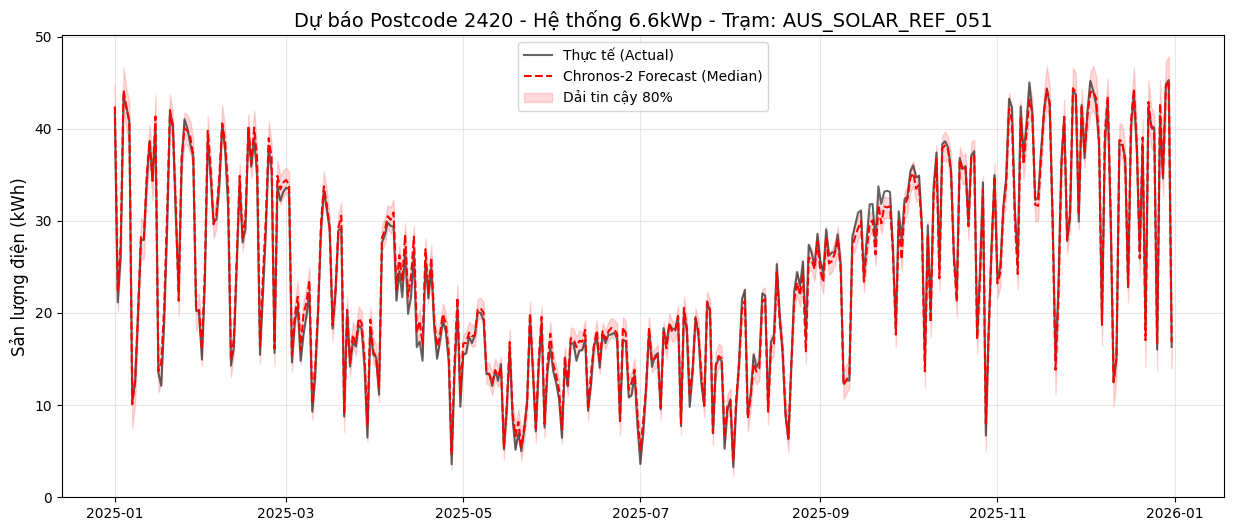

In [ ]:
#  Intialize Pipeline (truyền đủ data để mapping)
pipeline2 = SolarForecastingPipeline(
    model_path="/content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars_6_1e_6_300_8",
    df_main=pd.read_csv("/content/drive/MyDrive/TT/data/postcode_to_solar_ref_lookup.csv")
)
#  Loading model
pipeline2.load_models()

# Input:post code and KWp capacity

predictions = pipeline2.run_pipeline(
    postcode=2420,
    capacity_kwp=6.6
)

Successful loading model!
Selected station:
Postcode     : 2420
Solar ref ID : AUS_SOLAR_REF_001
Ref lat/long : -32.239696, 151.685456
Date range:
Context  : 2024-05-18 -> 2026-05-17
Forecast : 2026-05-18 -> 2027-05-17
Loading NASA data of coordinate (-32.2397, 151.6855) from 2024-05-18 to 2026-05-17...
Đang tiến hành dự báo với AutoGluon...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

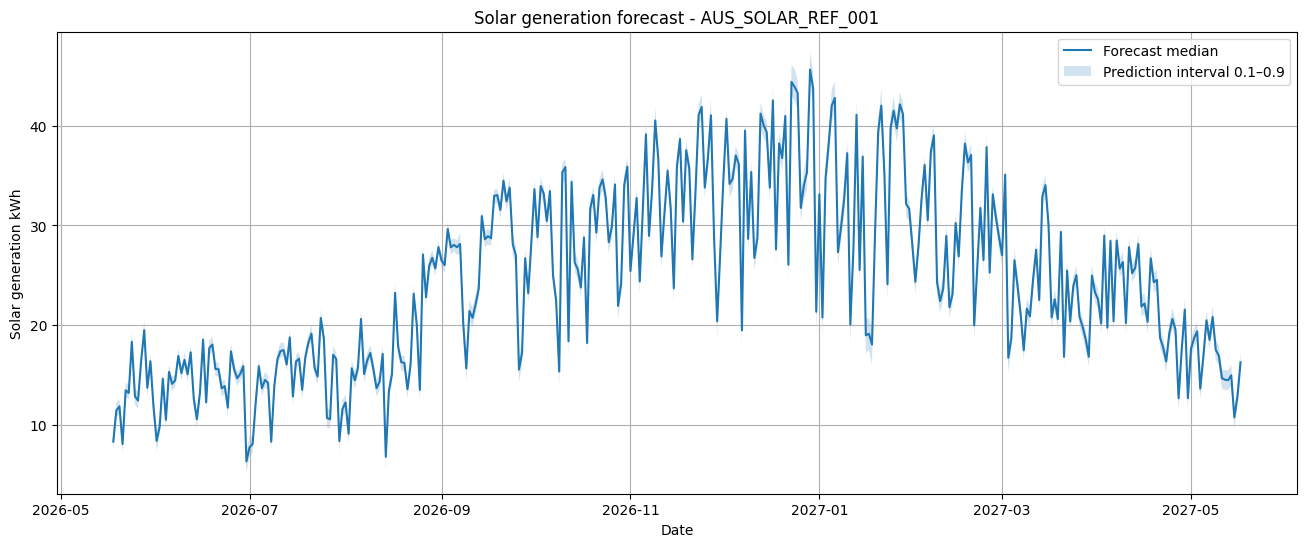

In [7]:
postcode_lookup_df = pd.read_csv(
    "/content/drive/MyDrive/TT/data/postcode_to_solar_ref_lookup.csv"
)

pipeline2 = SolarForecastingPipeline(
    model_path="/content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars_6_1e_6_300_8",
    df_main=postcode_lookup_df
)

pipeline2.load_models()

predictions = pipeline2.run_pipeline(
    postcode=2420,
    capacity_kwp=6.6
)